In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from src.config.clients import get_supabase_client

In [2]:
df = pd.read_csv("data/scoring_data_by_fit.csv")
df.head()

,score,domain
0,2,14trees.com
1,0,2050materials.com
2,0,3deusdynamics.com
3,3,accenta.ai
4,3,accessenergys.com


In [3]:
# Retrieve from supabase company_embeddings table the embeddings for the domains in col solution_and_use_cases_embedding
dimension = "solution_and_use_cases_embedding"
client = get_supabase_client()
embeddings = client.table("company_embeddings").select(f"domain,{dimension}").in_("domain", list(df["domain"].values)).execute().data
embeddings_map = {row["domain"]: row[dimension] for row in embeddings}

In [4]:
print(f"Number of domains in df: {len(df)}")
df["embeddings"] = df["domain"].apply(lambda x: np.fromstring(embeddings_map.get(x).strip("[]"), sep=",") if embeddings_map.get(x) else None)
df = df[df["embeddings"].notna()]
print(f"Number of domains in df after mapping: {len(df)}")


Number of domains in df: 557
Number of domains in df after mapping: 306


In [5]:
# Count values on score col
df.rename(columns={"embeddings": "x", "score": "y"}, inplace=True)
print(df["y"].value_counts())
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["y"])



y
2    131
3     95
1     42
0     38
Name: count, dtype: int64


In [6]:

X = np.stack(train_df["x"].values)
y = train_df["y"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



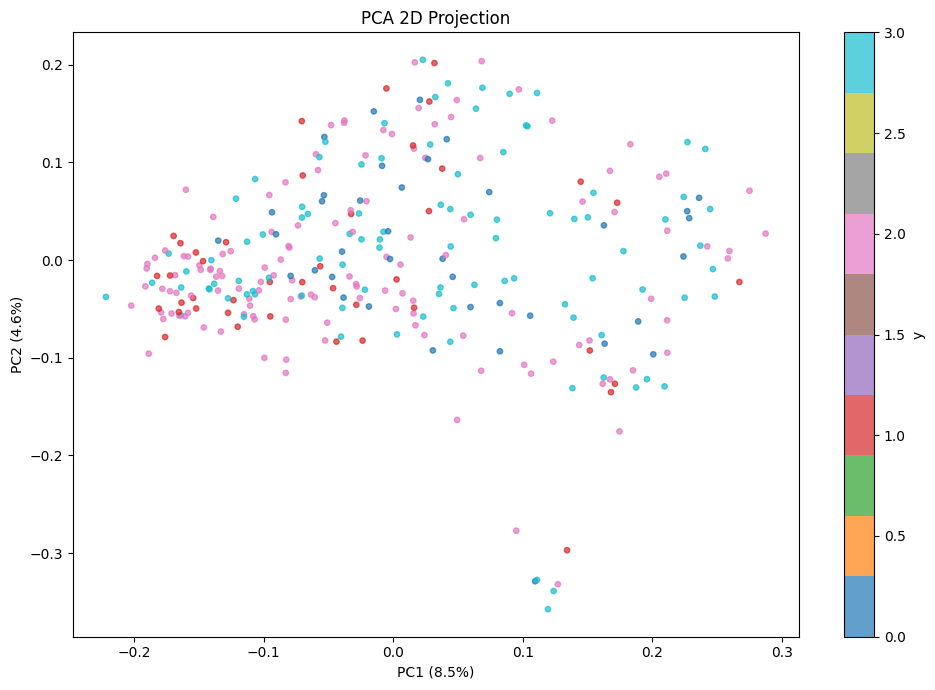

In [7]:
from sklearn.decomposition import PCA

def plot_pca(df):
    X = np.stack(df["x"].values)
    y = np.stack(df["y"].values)

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10", alpha=0.7, s=15)
    plt.colorbar(scatter, label="y")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.title("PCA 2D Projection")
    plt.tight_layout()
    plt.show()

plot_pca(df)



In [8]:
# Cell 0 - Custom Nearest Neighbor Model
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from scipy.spatial.distance import cdist

class NearestVectorClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X
        self.y_train_ = y
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        dists = cdist(X, self.X_train_, metric="cosine")
        nearest = dists.argmin(axis=1)
        return self.y_train_[nearest]

In [9]:


models = {
    "Nearest Vector (cosine)": Pipeline([
        ("clf", NearestVectorClassifier())
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", random_state=42))
    ]),
}



In [10]:
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv)
    results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Nearest Vector (cosine): 0.3852 ± 0.0565
Logistic Regression: 0.4224 ± 0.0554
Random Forest: 0.4919 ± 0.0526
SVM (RBF): 0.4920 ± 0.0486


/var/folders/_s/grxhyczx135dcrhc7pzfhkxr0000gn/T/ipykernel_81650/1315066782.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys())


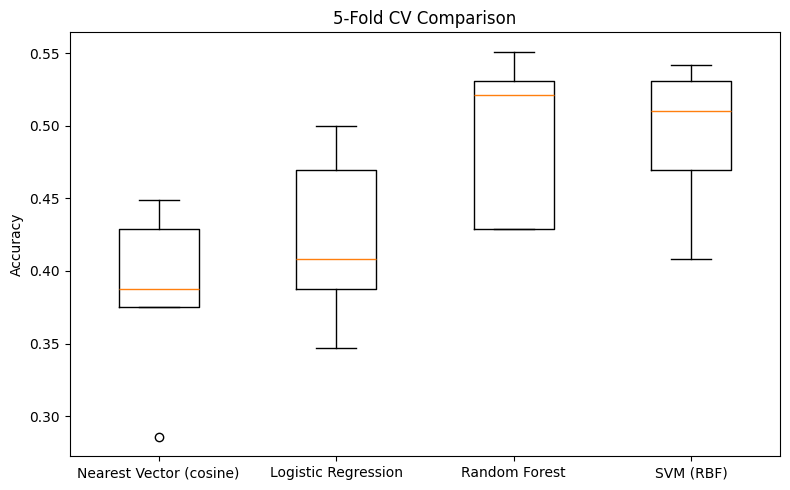

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(results.values(), labels=results.keys())
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold CV Comparison")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
# Retrieve the closest duo of companies having 0 and 3 as scores

# 1. filter df for 0 and 3
df0 = df[df["y"].isin([0])]
df3 = df[df["y"].isin([1])]
# 2. compute the cosine distance between the embeddings

# Compute cosine distance between embeddings
distances = cosine_similarity(np.stack(df0["x"].values), np.stack(df3["x"].values))

# Get the indices of the top 3 closest pairs
for index in np.argsort(distances, axis=None)[-3:]:
    closest_pairs = np.unravel_index(index, distances.shape)
    distances[closest_pairs]
    # Retrieve the companies
    company1 = df0.iloc[closest_pairs[0]]
    company2 = df3.iloc[closest_pairs[1]]

    print(f"Company 1: {company1['domain']} with score {company1['y']}")
    print(f"Company 2: {company2['domain']} with score {company2['y']}")
    print(f"Distance: {distances[closest_pairs]}")
    print("--------------------------------")
    





Company 1: carbonable.io with score 0
Company 2: qualisflow.com with score 1
Distance: 0.8957319162029662
--------------------------------
Company 1: isybot.com with score 0
Company 2: canvas.build with score 1
Distance: 0.8980668481482647
--------------------------------
Company 1: tripleye.com with score 0
Company 2: aim.vision with score 1
Distance: 0.9146121278750687
--------------------------------


In [17]:
## Custom accuracy
## The neighbourg classes will be validated by this accuracy metric
def custom_accuracy(y_true, y_pred):
    # Neighbourg classes will be validated by this accuracy metric
    # For example, if true was 2 but predicted was 1, it will be considered as a correct prediction
    classes_order = [0,3,2,1]
    y_true_order = np.array([classes_order.index(y) for y in y_true])
    y_pred_order = np.array([classes_order.index(y) for y in y_pred])
    diff = np.abs(y_true_order - y_pred_order)
    return np.mean(diff <= 1)

# Define callable scoring to run cross validation
def scoring_callable(model, X, y):
    y_pred = model.predict(X)
    return custom_accuracy(y, y_pred)

# Run cross validation with custom accuracy
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring_callable)
    results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")




Nearest Vector (cosine): 0.8279 ± 0.0206
Logistic Regression: 0.8647 ± 0.0333
Random Forest: 0.9181 ± 0.0221
SVM (RBF): 0.9139 ± 0.0152


[
  {
    "domain": "hexana.fr",
    "description": "Hexana is a French nuclear energy company developing a fourth-generation modular energy platform designed to decarbonize energy-intensive industries. A spin-off from the CEA and a laureate of the France 2030 program, the company provides a solution that combines sodium-cooled small modular reactors (SMRs) with integrated thermal storage. The platform serves as a flexible, carbon-free alternative to fossil fuels, delivering both high-temperature heat and stable electricity for heavy industry and critical infrastructure.",
    "detailed_solution": "The company provides a modular energy platform comprising two to six sodium-cooled fast neutron reactors (SMRs). This system is designed for cogeneration, meaning it simultaneously produces high-temperature process heat and carbon-free electricity. A core component of the solution is an integrated thermal storage system that allows the operator to store heat and deliver energy flexibly according to grid or industrial demand, decoupling the reactor's steady-state operation from the variable consumption of the end-user."
  },
  {
    "domain": "otrera.fr",
    "description": "Otrera is a French deeptech company developing fourth-generation Sodium-cooled Fast Reactors (SFR) designed for modularity, safety, and energy sovereignty. As a spin-off of the CEA, the company provides a sustainable nuclear solution capable of co-generating competitive electricity and heat for industrial and territorial applications. By utilizing MOX fuels derived from spent nuclear waste, Otrera enables a circular fuel cycle that significantly reduces environmental impact and resource dependency.",
    "detailed_solution": "The company offers a modular loop-type sodium-cooled fast reactor (SFR) architecture. The solution features a compact design with six 50 MWth modules and a vessel under 3 meters, optimized for factory prefabrication and deployment on sites smaller than 5 hectares. Key architectural innovations include three vessels in alternating operation (two in production, one in cooling) to allow for internal fuel cooling without external storage pools, and the use of sodium-gas heat exchangers to eliminate the chemical risks associated with traditional sodium-water reactions."
  }
]